In [1]:
from math import exp
import copy
import numpy as np
import matplotlib.pyplot as plt
from operator import attrgetter

## Nonstationary Bandit Environment

In [2]:
# Gaussian Process with Radial Basis Function Kernel
def rbf_kernel(x1, x2, variance = 1):
    return exp(-1 * ((x1-x2) ** 2) / (2*variance))

def gram_matrix(xs,var):
    return [[rbf_kernel(x1,x2,variance=var) for x2 in xs] for x1 in xs]

def generate_mean_rewards(n_arms=5,smoothness=1):
    xs = np.arange(0, 5, 0.025)
    mean = [0 for x in xs]
    gram = gram_matrix(xs, var=smoothness)
        
    all_mean_rewards = []
    for i in range(n_arms):
        mus = np.random.multivariate_normal(mean, gram)
        all_mean_rewards.append(mus)
    return np.vstack(all_mean_rewards)

def generate_rewards(mean_rewards, noise_var=1):
    rewards = mean_rewards + np.random.normal(0,np.sqrt(noise_var),size=mean_rewards.shape)
    return rewards

## Examining the Nonstationary Environment

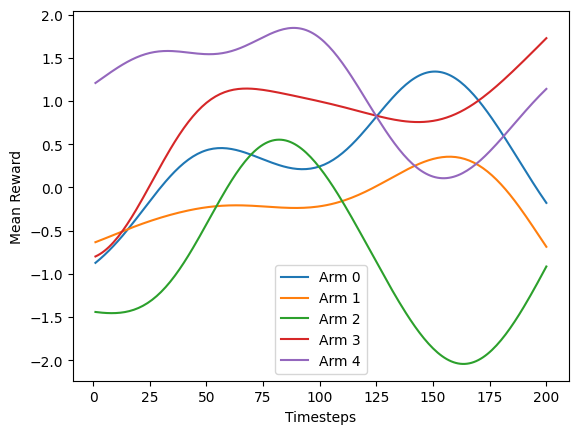

In [3]:
mean_rewards = generate_mean_rewards(smoothness=1)
plt.figure()
for k in range(len(mean_rewards)):
    plt.plot(np.arange(1,len(mean_rewards[k])+1), mean_rewards[k], label='Arm {}'.format(k))
plt.ylabel('Mean Reward')
plt.xlabel('Timesteps')
plt.legend()
plt.show()

## Generating Rewards

In [4]:
rewards = generate_rewards(mean_rewards, noise_var=1)

## Solutions

In [5]:
class Arm:
    def __init__(self, index, mu_t_a, sigma):
        self.index = index
        self.numplays = 0.0
        self.mu_t_a = mu_t_a
        self.sigma = sigma
        self.totrew = 0.0
        self.avgrew = 0.0

    def sample(self, t):
        return np.random.normal(self.mu_t_a[t], np.sqrt(self.sigma))

    def update(self, rew):
        self.numplays += 1
        self.totrew += rew
        self.avgrew = self.totrew / self.numplays

    def play(self, t):
        rew = self.sample(t)
        self.update(rew)
        return rew

def GetArms(K, mu_t, noise_var):
    arms = []
    for i in range(K):
        arms.append(Arm(i, mu_t[i], noise_var))
    return arms

In [6]:
# might be worth changing the formula for cb
def UpdateCBs(arm, T, K):
    cb = np.sqrt(2 * arm.sigma * (np.log(T * K)) / arm.numplays)
    arm.ucb = arm.avgrew + cb
    arm.lcb = arm.avgrew - cb

def UpperConfidenceBound(arms, T):
    t = 0
    rew = np.zeros(T)
    reg = np.zeros(T)
    K = len(arms)

    for arm in arms:
        rew[t] = arm.play(t)
        reg[t] = max(arm.mu_t_a[t] for arm in arms) - arm.mu_t_a[t]
        UpdateCBs(arm, T, K)
        t += 1
        if t == T:
            break

    while t < T:
        arm = max(arms, key=attrgetter('ucb'))
        rew[t] = arm.play(t)
        reg[t] = max(arm.mu_t_a[t] for arm in arms) - arm.mu_t_a[t]
        UpdateCBs(arm, T, K)
        t += 1

    return rew, reg

In [7]:
def ThompsonSampling_Gaussian(arms, priors, T):
    t = 0
    rew = np.zeros(T)
    reg = np.zeros(T)
    K = len(arms)
    Gaussian_params = np.zeros((T, K, 2))

    posterior = 1.0*priors

    while t < T:
        thompson_samples = np.zeros(K)
        for arm in arms:
            thompson_samples[arm.index] = np.random.normal(posterior[arm.index, 0],
                                                           np.sqrt(posterior[arm.index, 1]))
        
        best_index = np.argmax(thompson_samples)
        arm = arms[best_index]
        rew[t] = arm.play(t)
        reg[t] = max([arm.mu_t_a[t] for arm in arms]) - arm.mu_t_a[t]

        mu_0 = posterior[best_index, 0]
        sigma2_0 = posterior[best_index, 1]
        sigma2 = arm.sigma
        posterior[best_index] = [((mu_0 / sigma2_0) + (rew[t] / sigma2)) / ((1 / sigma2) + (1 / sigma2_0)),
                                  1 / ((1 / sigma2) + (1 / sigma2_0))]

        Gaussian_params[t] = posterior
        t += 1

    return rew, reg, Gaussian_params

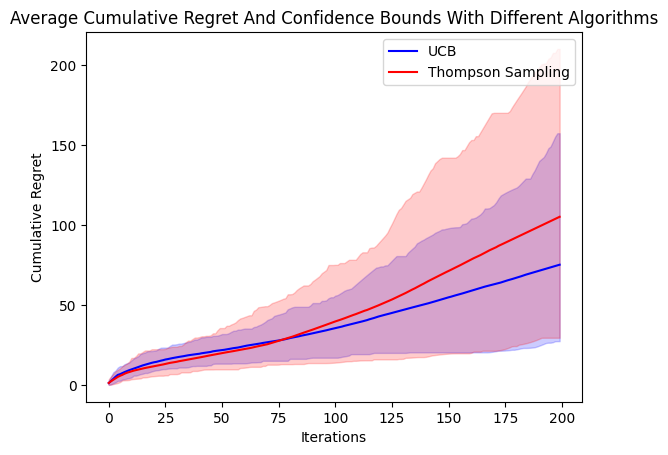

In [8]:
K, T, noise_var = 5, 200, 1
n_sim = 100

regrets = np.zeros((n_sim, T))

for sim in range(n_sim):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, noise_var)
    for arm in bandits_env:
        setattr(arm, 'ucb', 1000.0)
        setattr(arm, 'lcb', -1000.0)
    regrets[sim] = np.cumsum(UpperConfidenceBound(bandits_env, T)[1])

mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[94]
CB5 = sorted_regrets[4]
plt.plot(mean_regrets, label='UCB', color='b')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='b')

regrets = np.zeros((n_sim, T))
standard_priors = np.tile(np.array([0, 10]), (K, 1))

for sim in range(n_sim):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, noise_var)
    regrets[sim] = np.cumsum(ThompsonSampling_Gaussian(bandits_env, standard_priors, T)[1])

mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[94]
CB5 = sorted_regrets[4]
plt.plot(mean_regrets, label='Thompson Sampling', color='r')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='r')

plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Cumulative Regret')
plt.title('Average Cumulative Regret And Confidence Bounds With Different Algorithms')
plt.show()

In [9]:
def PredictiveSampling(arms, T):
    t = 0
    rew = np.zeros(T)
    reg = np.zeros(T)
    K = len(arms)
    # Posterior distribution, similar to priors but adjusted as we observe rewards
    predictive_info = np.zeros((T, K))

    while t < T:
        # Step 1: Sample future reward sequence for each arm to estimate durability
        sampled_rewards = np.zeros(K)
        for arm in arms:
            # This is where PS differs from TS: conditioning on future durability
            sampled_rewards[arm.index] = np.mean([arm.mu_t_a[min(t + j, T - 1)]
                                                  for j in range(1, T - t)])  # sampling future reward durability

        # Step 2: Select arm based on sampled future reward sequence
        best_index = np.argmax(sampled_rewards)
        arm = arms[best_index]
        
        # Step 3: Play selected arm and update observations
        rew[t] = arm.play(t)
        reg[t] = max([arm.mu_t_a[t] for arm in arms]) - arm.mu_t_a[t]
        
        # Update durability information for the arm
        predictive_info[t] = sampled_rewards
        t += 1

    return rew, reg, predictive_info


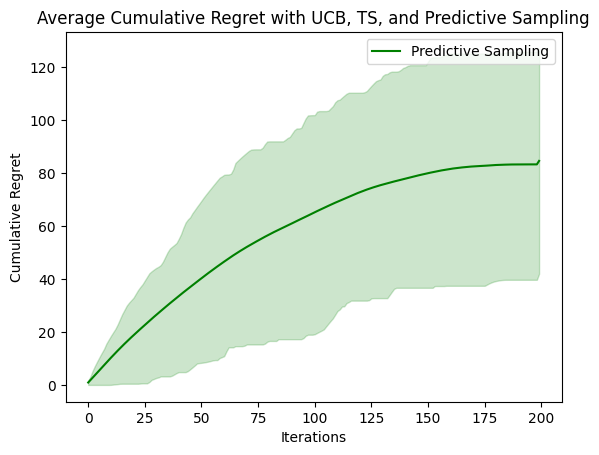

In [11]:
# Define simulation parameters
K, T, noise_var = 5, 200, 1
n_sim = 100

# Run Predictive Sampling and collect regrets
regrets = np.zeros((n_sim, T))

for sim in range(n_sim):
    mean_rewards = generate_mean_rewards()
    bandits_env = GetArms(K, mean_rewards, noise_var)
    regrets[sim] = np.cumsum(PredictiveSampling(bandits_env, T)[1])

# Plotting results for Predictive Sampling
mean_regrets = np.mean(regrets, axis=0)
sorted_regrets = np.sort(regrets, axis=0)
CB95 = sorted_regrets[79]
CB5 = sorted_regrets[19]
plt.plot(mean_regrets, label='Predictive Sampling', color='g')
plt.fill_between(np.arange(T), CB5, CB95, alpha=0.2, color='g')

# Final plot with UCB and TS comparison
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Cumulative Regret')
plt.title('Average Cumulative Regret with UCB, TS, and Predictive Sampling')
plt.show()
